##### **AI Usage Disclosure:**
I have used AI tools in this assignment as an additional resource to help me come up with ideas,understand concepts,and fix small coding errors when I was doing the exploratory analysis and visualization. AI assistance made me more efficient and helped me make my presentation clearer,however,the parts of the work that were chosen,the making of features,the ways of presenting data,the interpretations,and the general working out of the project were all done by me.

Basically,AI was used as a tutor that helped me learn rather than a tool that gave me the answers,and I thoroughly checked,changed,and approved all the stuff produced to make sure they represented my own understanding of the dataset and the assignment objectives.

# Titanic Dataset: Exploratory Data Analysis and Visualization

In order to determine the passenger survival trends,this notebook does an exploratory analysis of the Titanic dataset. In order to find the links between demographic,socioeconomic,and travel-related factors including passenger class,age,fare,and family structure,it mostly comprises of data inspection,feature discovery,and visualization approaches.

In addition to doing exploratory data analysis,the initiative addresses data visualization's ethical concerns. Two sets of visualizations are made: one that follows best standards for honest,accurate,and clear communication,and the other that is specifically made to show how one might mislead the perception of the graphic by adjusting scale,design,encoding,or framing. To look how choices about presentations affects audience perception even when the related facts stays the same is the motive.

By emphasizing both technical analytical abilities and critical thinking for responsible data communication,the notebook reinforces the significance of ethical decision-making,openness,and clarity in data science.

#### Author: Tirth Nitinkumar Laheri (M01665727)  
#### Course: DATA 6550

### Section 1: Importing Required Libraries
- Imports libraries required for data manipulation, numerical computation, and visualization.
- Configures visualization styles and display settings to maintain consistency throughout the analysis.
- Prepares the programming environment for exploratory data analysis and plotting tasks.

In [23]:
#ignore warnings
import warnings
warnings.filterwarnings("ignore")

#data manipulation
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#visualization helpers
from matplotlib.ticker import PercentFormatter

#visualization settings
sns.set_theme(style="whitegrid")

#display settings for eda
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)

### Section 2: Loading the Datasets
- Loads the Titanic training, testing, and submission datasets into pandas dataframes.
- Verifies dataset dimensions and previews sample records to confirm successful loading.
- Establishes the primary working dataset used for survival analysis and visualization.

In [24]:
#load datasets
train=pd.read_csv("Data/train.csv")
test=pd.read_csv("Data/test.csv")
gender_submission=pd.read_csv("Data/gender_submission.csv")

In [25]:
print("Train Dataset:")
print("Training data shape:",train.shape)
train.head(8)

Train Dataset:
Training data shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [26]:
print("Test Dataset:")
print("Test data shape:",test.shape)
test.head(8)

Test Dataset:
Test data shape: (418, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S


In [27]:
print("gender_submission Dataset:")
print("gender_submission data shape:",gender_submission.shape)
gender_submission.head(8)

gender_submission Dataset:
gender_submission data shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0


### Section 3: Working Dataset Overview
- Examines dataset structure, data types, and summary statistics.
- Identifies missing values and evaluates overall data quality.
- Provides an initial understanding of variables relevant to survival prediction.

In [28]:
#basic information about training data
train.info()

train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
#check survival distribution
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [30]:
#check missing values
train.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

### Section 4: Exploratory Data Analysis and Feature Exploration
- Explores relationships between passenger characteristics and survival outcomes.
- Engineers additional features such as family size and fare categories to enhance analysis.
- Uses statistical summaries and visualizations to uncover meaningful patterns in the data.

In [31]:
#family size=siblings/spouse + parents/children + passenger
train['FamilySize']=train['SibSp'] + train['Parch'] + 1

#create family group categories
train['FamilyGroup'] = train['FamilySize'].apply(
    lambda x: 'Alone' if x == 1
    else 'Small Family (2-4)' if 2 <= x <= 4
    else 'Large Family (5+)'
)

train[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [32]:
train['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [33]:
#average survival rate by family size
train.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

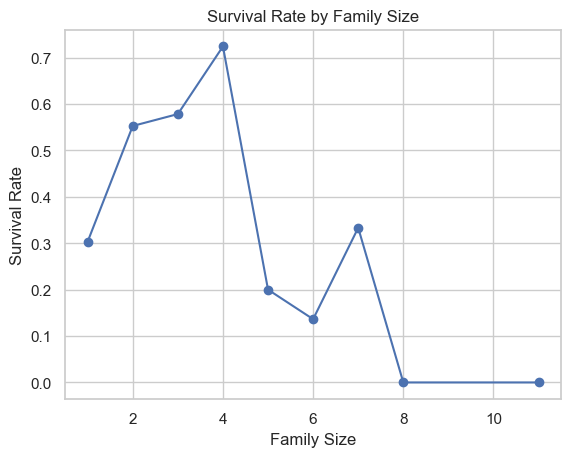

In [34]:
#visualizing survival rate by family size
train.groupby('FamilySize')['Survived'].mean().plot(kind='line',marker='o')

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

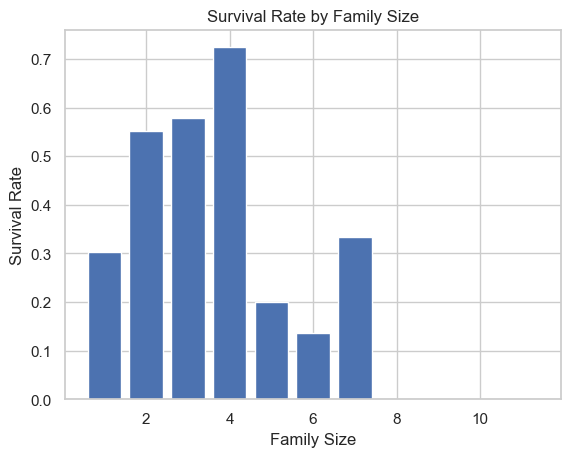

,survival_rate,count
FamilySize,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


In [35]:
#calculate survival rate and count by family size
family_stats=train.groupby('FamilySize').agg(
    survival_rate=('Survived','mean'),
    count=('Survived','count')
)

#bar plot of survival rate
plt.figure()
plt.bar(family_stats.index,family_stats['survival_rate'])

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

family_stats

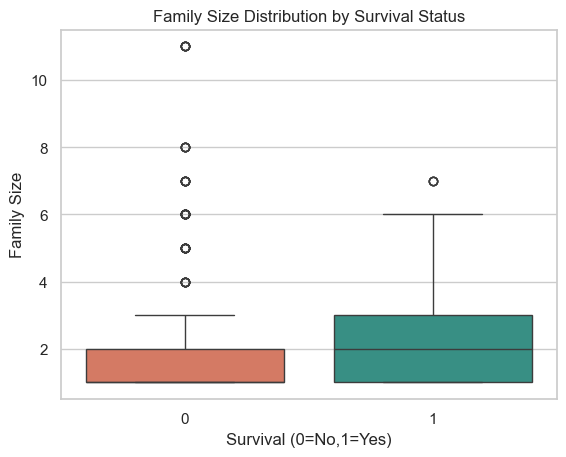

In [36]:
#family size distribution by survival status
plt.figure()

sns.boxplot(
    x='Survived',
    y='FamilySize',
    data=train,
    palette=['#e76f51','#2a9d8f']
)

plt.title("Family Size Distribution by Survival Status")
plt.xlabel("Survival (0=No,1=Yes)")
plt.ylabel("Family Size")

plt.show()

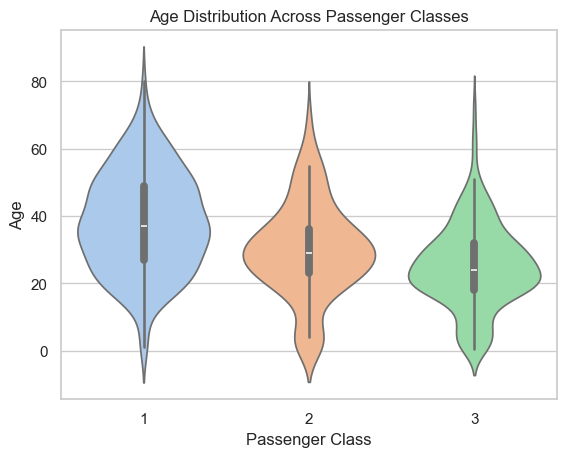

In [37]:
#age distribution across passenger classes
plt.figure()

sns.violinplot(
    x='Pclass',
    y='Age',
    data=train,
    palette='pastel'
)

plt.title("Age Distribution Across Passenger Classes")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

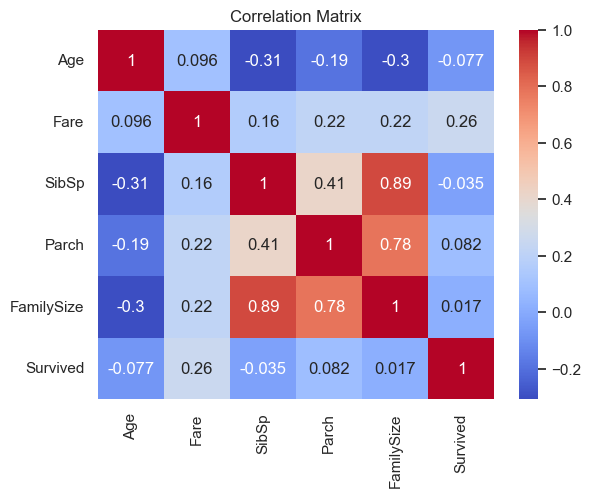

In [38]:
#correlation matrix for numerical variables
plt.figure()

corr=train[['Age','Fare','SibSp','Parch','FamilySize','Survived']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

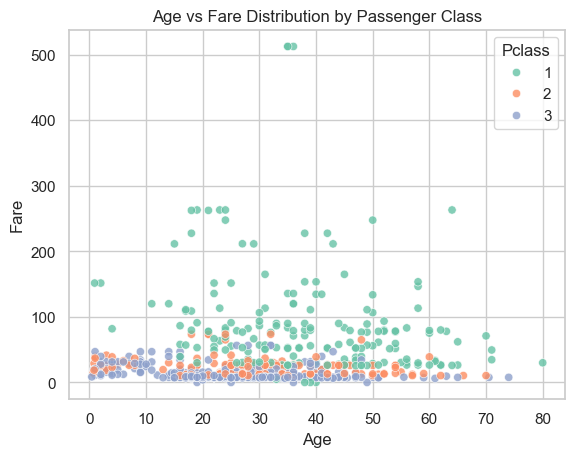

In [39]:
#age vs fare relationship with class coloring
plt.figure()

sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Pclass',
    data=train,
    palette='Set2',
    alpha=0.8
)

plt.title("Age vs Fare Distribution by Passenger Class")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

In [40]:
#creating fare categories
train['FareCategory']=pd.qcut(
    train['Fare'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

train['FareCategory'].value_counts()

FareCategory
Medium       224
Low          223
High         222
Very High    222
Name: count, dtype: int64

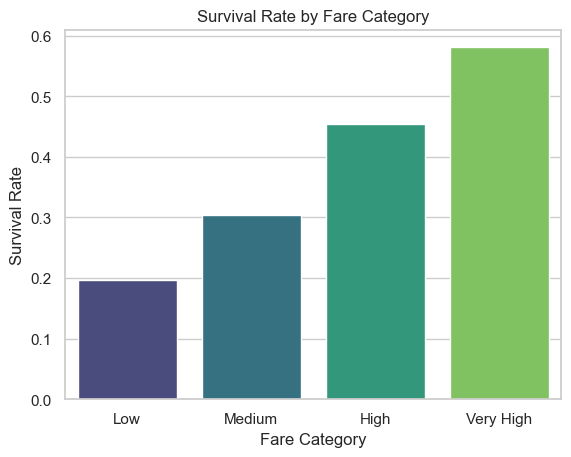

FareCategory
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64

In [41]:
#survival rate by fare category
fare_survival=train.groupby('FareCategory')['Survived'].mean()
plt.figure()
sns.barplot(
    x=fare_survival.index,
    y=fare_survival.values,
    palette='viridis'
)

plt.title("Survival Rate by Fare Category")
plt.xlabel("Fare Category")
plt.ylabel("Survival Rate")

plt.show()

fare_survival

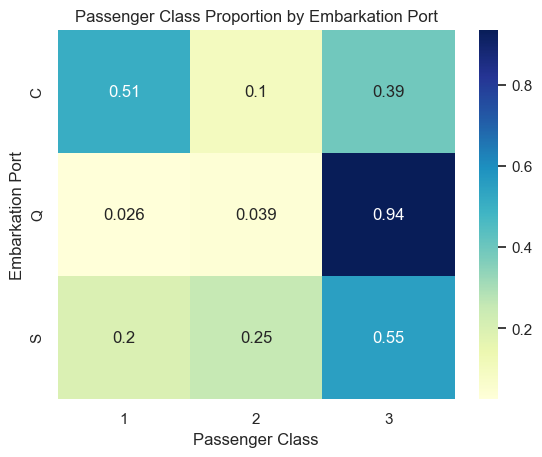

Pclass,1,2,3
Embarked,,,
C,0.505952,0.101190,0.392857
Q,0.025974,0.038961,0.935065
S,0.197205,0.254658,0.548137


In [42]:
#passenger class distribution by embarkation port
cross_tab=pd.crosstab(train['Embarked'],train['Pclass'],normalize='index')
plt.figure()
sns.heatmap(cross_tab,annot=True,cmap='YlGnBu')
plt.title("Passenger Class Proportion by Embarkation Port")
plt.xlabel("Passenger Class")
plt.ylabel("Embarkation Port")
plt.show()
cross_tab

### Section 5: Ethical Visualizations
- Presents visualizations designed using clear, accurate, and responsible visualization principles.
- Uses appropriate scales, labeling, and chart selection to communicate insights truthfully.
- Demonstrates how effective visualization design supports correct interpretation of data.

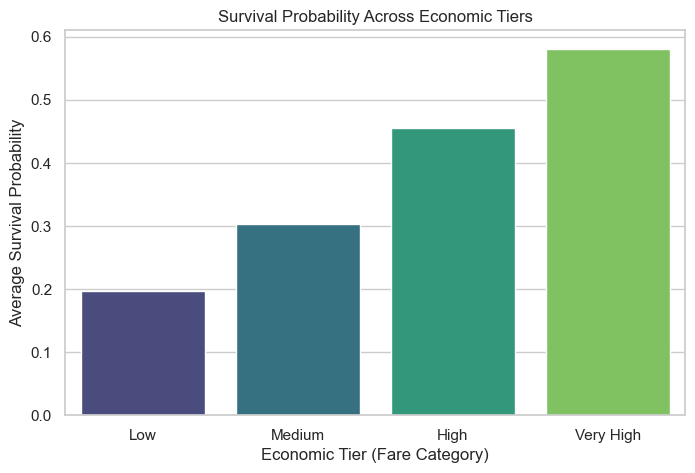

In [43]:
#survival by fare category
plt.figure(figsize=(8,5))
sns.barplot(
    x='FareCategory',
    y='Survived',
    data=train,
    estimator=np.mean,
    errorbar=None,
    palette='viridis'
)

plt.title("Survival Probability Across Economic Tiers")
plt.xlabel("Economic Tier (Fare Category)")
plt.ylabel("Average Survival Probability")

plt.show()

#### Explanation:
- Survival probability increases steadily as the fare category rises.
- Passengers who paid higher fare likely tend to survive more than the ones who pay the lower fare.
- This trend suggests that according to the dataset, the socioeconomic status likely influence the survival rates due to better cabin allocations or due improved evacuation facilities.
- The upward trend is consistent which indicates meaningful relationship between fare and survival rather than being random variation.
- The visualization allows clear comparison across categories, aiding viewers to understand the survival differences between different economic tiers.

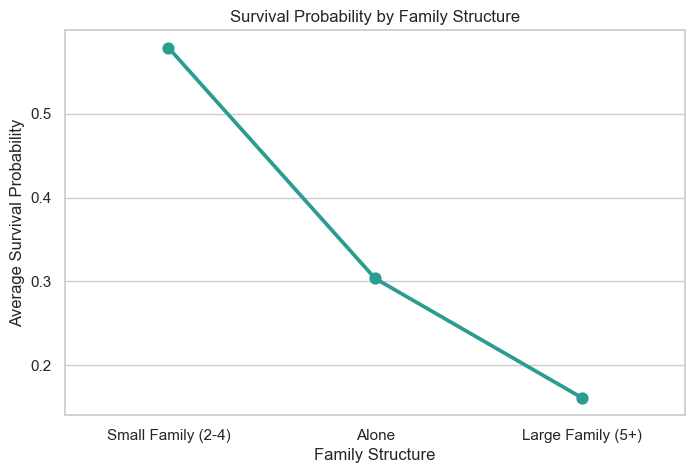

In [44]:
#survival by family structure
plt.figure(figsize=(8,5))

sns.pointplot(
    x='FamilyGroup',
    y='Survived',
    data=train,
    estimator=np.mean,
    errorbar=None,
    color='#2a9d8f'
)

plt.title("Survival Probability by Family Structure")
plt.xlabel("Family Structure")
plt.ylabel("Average Survival Probability")

plt.show()

#### Explanation:
- The likelihood of survival is greatest for smaller family groups versus people traveling alone or in larger families.
- Individuals traveling alone have a moderate rate of survival, this implies that they had little to no support or assistance in evacuating compared to those in smaller family groups.
- More number of member exhibit a declining rate of survival. This may be due to difficulties with coordination or slower evacuation times during the event.
- Overall, the chart states that family structure is directly influenced survival outcomes on the Titanic.

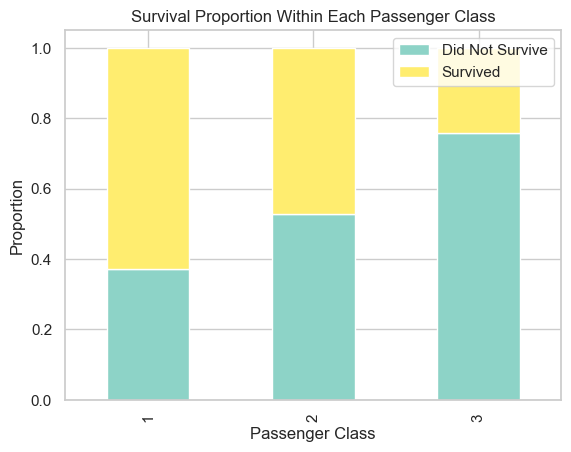

In [45]:
#survival proportion by passenger class
class_survival=pd.crosstab(
    train['Pclass'],
    train['Survived'],
    normalize='index'
)

class_survival.plot(
    kind='bar',
    stacked=True,
    colormap='Set3'
)

plt.title("Survival Proportion Within Each Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Proportion")
plt.legend(['Did Not Survive','Survived'])
plt.show()

#### Explanation:
- People in the 1st Class had a higher proportion of survivors compared to others.
- The survival probability decreases as the passenger class moves from lower to higher classes.
- This pattern indicates that passenger class and its representation of social/economic status and cabin location played a substantial part in determining each passenger's chance of survival during the disaster.

### Section 6: Intentionally Misleading Visualizations
- Creates visualizations that intentionally manipulate design elements to distort interpretation.
- Demonstrates issues such as inappropriate chart types, visual clutter, and exaggerated encoding.
- Highlights how visualization choices influence perception and the importance of ethical communication.

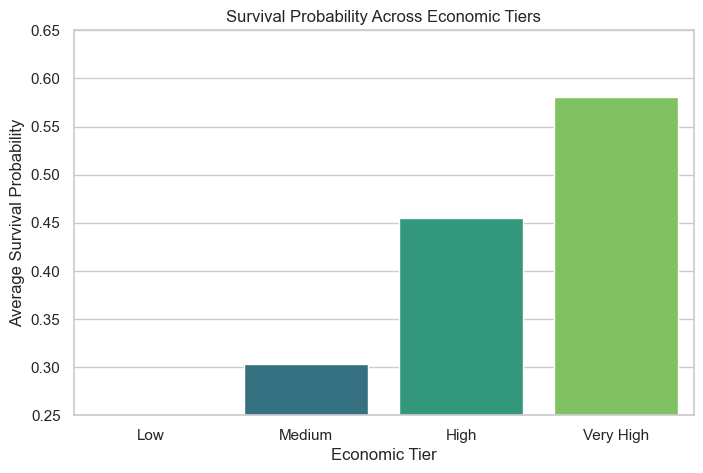

In [46]:
#misleading visualization:truncated y-axis exaggeration
plt.figure(figsize=(8,5))

sns.barplot(
    x='FareCategory',
    y='Survived',
    data=train,
    estimator=np.mean,
    errorbar=None,
    palette='viridis'
)

plt.title("Survival Probability Across Economic Tiers")
plt.xlabel("Economic Tier")
plt.ylabel("Average Survival Probability")
plt.ylim(0.25,0.65)

plt.show()

#### Explanation:
- The y-axis does not start at zero, it gives a false sense of the differences in numbers being larger than they actually are.
- The truncated scale exaggerates the change in survival probability between categories.
- Viewers may think the gap between economic tiers is very large due to the zoomed-in axis.
- This shows how changing axis limits can easily mislead interpretation even when the data is correct.

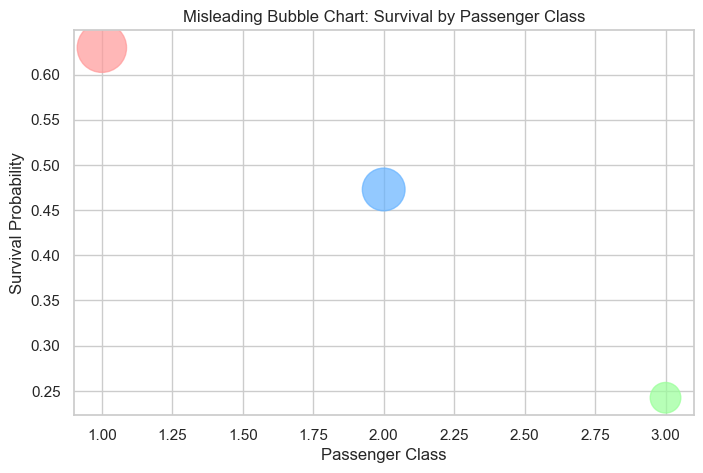

In [47]:
plt.figure(figsize=(8,5))

#compute survival rates by passenger class
class_survival=train.groupby('Pclass')['Survived'].mean().reset_index()

#create misleading bubble sizes
sizes=class_survival['Survived'] * 2000

plt.scatter(
    class_survival['Pclass'],
    class_survival['Survived'],
    s=sizes,
    c=['#ff9999','#66b3ff','#99ff99'],
    alpha=0.7
)

plt.title("Misleading Bubble Chart: Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Probability")
plt.show()

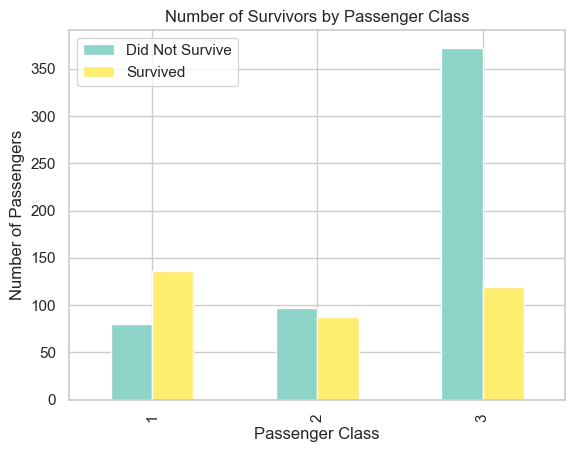

In [48]:
#misleading visualization 4: raw counts instead of proportions
count_chart=pd.crosstab(train['Pclass'],train['Survived'])

count_chart.plot(
    kind='bar',
    colormap='Set3'
)
plt.title("Number of Survivors by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(['Did Not Survive','Survived'])

plt.show()

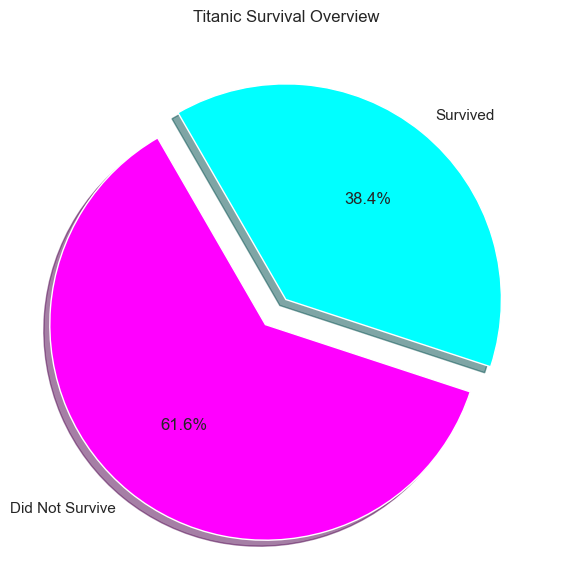

In [49]:
#misleading visualization: flashy pie chart
survival_counts=train['Survived'].value_counts()

plt.figure(figsize=(7,7))

colors=['#ff00ff','#00ffff']
explode=[0.15,0] 

plt.pie(
    survival_counts,
    labels=['Did Not Survive','Survived'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=120
)
plt.title("Titanic Survival Overview")
plt.show()

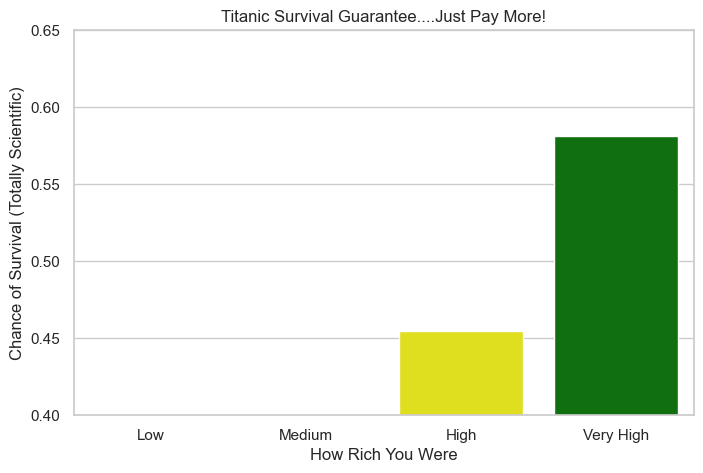

In [50]:
#sarcastic misleading visualization
plt.figure(figsize=(8,5))

sns.barplot(
    x='FareCategory',
    y='Survived',
    data=train,
    estimator=np.mean,
    errorbar=None,
    palette=['red','orange','yellow','green']
)
plt.ylim(0.4,0.65)

plt.title("Titanic Survival Guarantee....Just Pay More!")
plt.xlabel("How Rich You Were")
plt.ylabel("Chance of Survival (Totally Scientific)")

plt.show()

#### Explanation
- Data can be interpreted differently if sarcasm is used in the title and the axis labels of the chart or graph used to show data.
- By using a limited y-axis range, we are unable to see the whole scaled range of data, thus creating dramatic differences from one data point to another.
- Thus the visualizer has accomplished its goal to persuade the viewer rather than to accurately depict the data through poor visual design that will mislead the audience ethically!


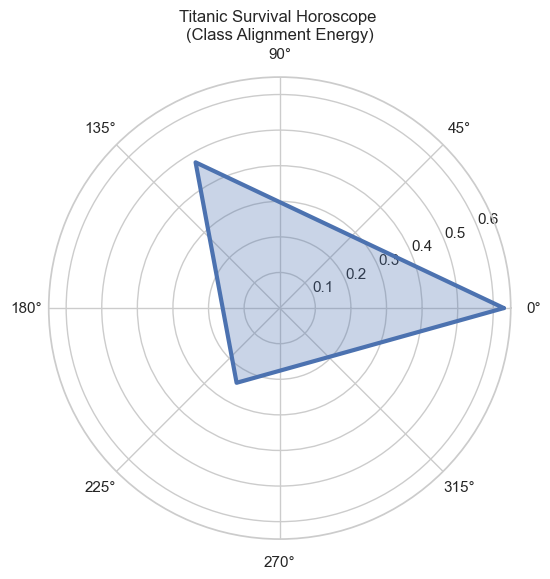

In [51]:
#unnecessary polar chart (AI generated)
import numpy as np

# survival by class
survival_rate=train.groupby('Pclass')['Survived'].mean()

angles=np.linspace(0,2*np.pi,len(survival_rate),endpoint=False)
values=survival_rate.values

# close the circle
angles=np.concatenate([angles,[angles[0]]])
values=np.concatenate([values,[values[0]]])

plt.figure(figsize=(6,6))
ax=plt.subplot(111,polar=True)

ax.plot(angles,values,linewidth=3)
ax.fill(angles,values,alpha=0.3)

ax.set_title("Titanic Survival Horoscope \n(Class Alignment Energy)")

plt.show()

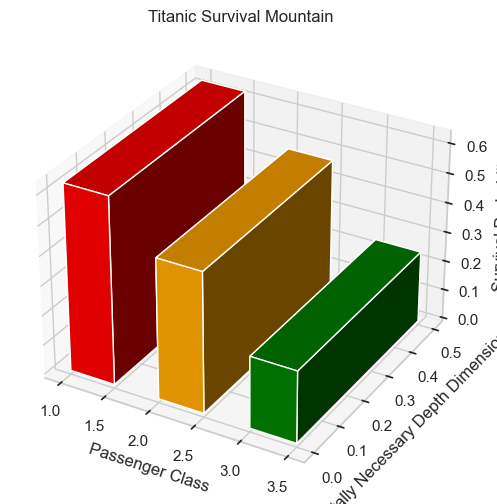

In [52]:
#unnecessary 3D chart
from mpl_toolkits.mplot3d import Axes3D

#compute survival rate by class
class_survival=train.groupby('Pclass')['Survived'].mean()

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')

x=class_survival.index
y=[0,0,0]  #fake dimension (meaningless)
z=class_survival.values

ax.bar3d(x,y,np.zeros_like(z),
         dx=0.5,dy=0.5,dz=z,
         color=['red','orange','green'],
         shade=True)

ax.set_title("Titanic Survival Mountain")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Totally Necessary Depth Dimension")
ax.set_zlabel("Survival Probability")

plt.show()

#### Explanation
- Using 3D Effects Generates Illusions of Form That Are Meaningless & Confusing To The Viewer
- Because depth and perspective distort the size of bars, it makes it hard for one to truly assess and compare survival possibilities.
- The visual design prioritizes appearance over clarity, reducing readability and accurate interpretation.
- Using unnecessary 3D elements demonstrates how adding complexity can mislead audiences instead of communicating information honestly.

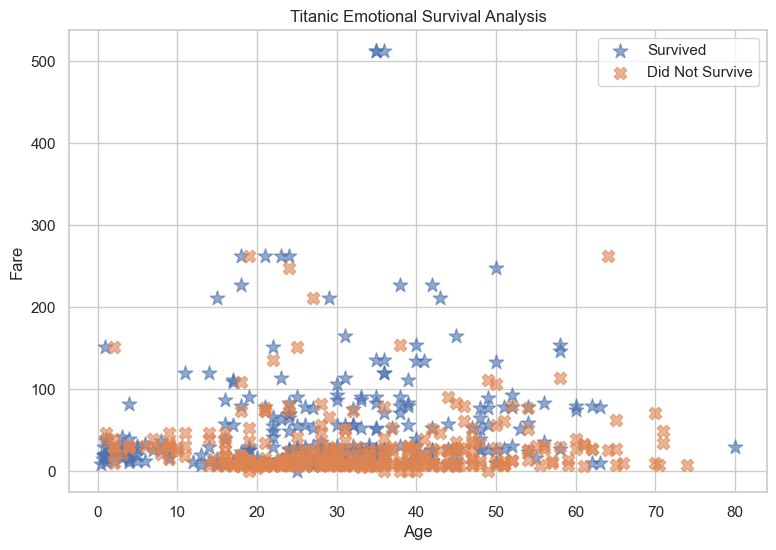

In [53]:
#emojiscatter
plt.figure(figsize=(9,6))

survived=train[train['Survived'] == 1]
not_survived=train[train['Survived'] == 0]
plt.scatter(
    survived['Age'],
    survived['Fare'],
    marker='*',   
    s=120,
    alpha=0.6,
    label='Survived'
)

plt.scatter(
    not_survived['Age'],
    not_survived['Fare'],
    marker='X', 
    s=80,
    alpha=0.6,
    label='Did Not Survive'
)

plt.title("Titanic Emotional Survival Analysis")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()
plt.show()

#### Explanation:
- Different symbol shapes draw attention away from the actual data relationships and reduce readability.
- Using symbolic markers (stars and crosses) introduces emotional meaning, which is not appropriate for objective data analysis.
- The oversized markers overlap heavily, hiding data points and preventing accurate comparison.
- This visualisation prioritizes visual style over clarity, demonstrating how poor design choices can negatively affect interpretation.